In [2]:
#=== COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "dplant227"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/HW1"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/dplant227/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/dplant227/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW1


# Homework 1: Completely Randomized Designs
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: February 6, 2026**

**INSTRUCTIONS:** You are a quality control analyst for a craft brewery experimenting with a new India Pale Ale (IPA). One key quality attribute of IPA is its bitterness, measured in International Bitterness Units (IBUs). The brewery wants to determine if the aging time (3, 4, or 5 weeks) affects the IBUs of the beer. To test this, the brewing team brews a single batch of the experimental IPA and divides it into aging tanks, with each tank randomly assigned to be aged for 3, 4, or 5 weeks. After aging, the IBUs of ten randomly selected bottles from each aging time are measured using a spectrophotometer. The data are in the file `IPA.xlsx`. With these data, I want you to:

**Question 1.** Briefly define the objective of this experiment

The objective of this experiment is to measure the IBU against the aging time.

**Question 2.** Specify the outcome variable

IBU

**Question 3.** Specify the independent variable. What are some possible lurking variables?

Aging time.

**Question 4.** Briefly explain why a completely randomized design may be appropriate for this experiment.

A completely randomized design is appropriate for this experiment as to eliminate any potential sources for variability to ensure that conclusions drawn from this experiment are accurate. Additionally, it ensures that each experimental unit has an equal chance to be in either treatment group.

**Question 5.** State the null and alternative hypotheses for this experiment.


H0 = There is no relationship between IBU and aging time.
Ha = There is a relationship between IBU and aging time.

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?



**Question 7.** Build a one-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

**Question 9.** Report the F-statistic and its associated p-value from the one-way ANOVA model. Which of our two hypotheses is more strongly supported? Why?

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which aging times are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses. Additionally, describe any limitations of the experiment and/or your analyses, and suggest potential improvements for future experiments of this nature.

<bound method NDFrame.head of       Weeks    IBU  aging_time
0   3 Weeks  39.41           3
1   3 Weeks  53.18           3
2   3 Weeks  35.31           3
3   3 Weeks  59.62           3
4   3 Weeks  40.95           3
5   3 Weeks  47.79           3
6   3 Weeks  56.88           3
7   3 Weeks  48.39           3
8   3 Weeks  54.21           3
9   3 Weeks  56.42           3
10  4 Weeks  63.75           4
11  4 Weeks  47.82           4
12  4 Weeks  71.70           4
13  4 Weeks  70.75           4
14  4 Weeks  67.81           4
15  4 Weeks  68.93           4
16  4 Weeks  55.42           4
17  4 Weeks  68.79           4
18  4 Weeks  54.45           4
19  4 Weeks  58.09           4
20  5 Weeks  61.66           5
21  5 Weeks  78.03           5
22  5 Weeks  71.78           5
23  5 Weeks  70.12           5
24  5 Weeks  73.57           5
25  5 Weeks  72.07           5
26  5 Weeks  69.75           5
27  5 Weeks  65.99           5
28  5 Weeks  74.19           5
29  5 Weeks  60.09           5>
        

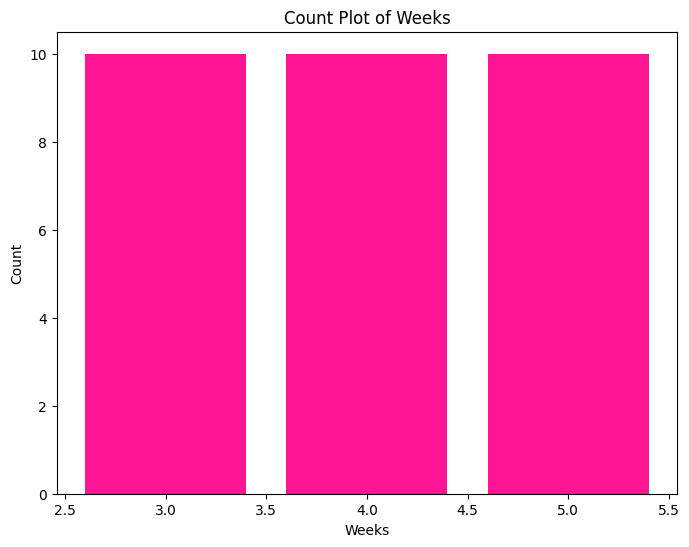

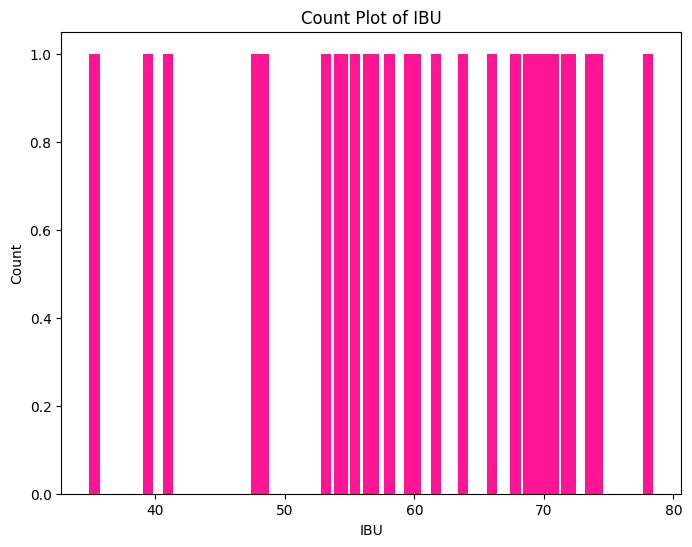

In [41]:
import numpy as np
import pandas as pd
import scipy as sp
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns

#import data#
ipa = pd.read_excel("IPA.xlsx", engine = 'openpyxl')

#Question 6 data integrity#

ipa.columns.tolist()
ipa.describe(include="all").T

mapping = {'3 Weeks': 3, '4 Weeks': 4, '5 Weeks': 5}

ipa['aging_time'] = ipa['Weeks'].map(mapping)

print(ipa.head)

ipa.columns.tolist()
print(ipa.describe(include="all").T)

##Data Visualization aging time
aging = ipa['aging_time'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(aging.index, aging.values, color='deeppink')
plt.title('Count Plot of Weeks')
plt.xlabel('Weeks')
plt.ylabel('Count')
plt.show()

ibus = ipa['IBU'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(ibus.index, ibus.values, color='deeppink')
plt.title('Count Plot of IBU')
plt.xlabel('IBU')
plt.ylabel('Count')
plt.show()

#Question 7 One-way ANOVA#